# ELSST Track 1: Exploratory Data Analysis

Explores the structure of the ELSST Track 1 dataset and concept pool before any modelling begins split sizes, genre and label-count distributions, passage and definition lengths, and cross-split consistency, closing with a summary of the properties that shape every section's design choices.

## 1. Setup & Data Loading

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Create project Folder

In [ ]:
import os

project_path = '/content/drive/MyDrive/ELSST_Project'
os.makedirs(project_path, exist_ok=True)
print("Project folder ready at:", project_path)

Project folder ready at: /content/drive/MyDrive/ELSST_Project


### Install Dependencies

In [ ]:
!pip install datasets -q

### Load Dataset from HuggingFace

In [ ]:
from datasets import load_dataset

dataset = load_dataset("JohnWang10086/elsst-track1")
print(dataset)

README.md:   0%|          | 0.00/3.42k [00:00<?, ?B/s]

train.jsonl: reconstructing file:   0%|          |  0.00B / 22.3MB            

train.jsonl: downloading bytes:           |  0.00B            

val.jsonl:   0%|          | 0.00/5.65M [00:00<?, ?B/s]

test_input.jsonl: reconstructing file:   0%|          |  0.00B / 11.1MB            

test_input.jsonl: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/2985 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/756 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1911 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'text', 'document_type', 'generation_labels', 'retrieval_labels'],
        num_rows: 2985
    })
    validation: Dataset({
        features: ['id', 'text', 'document_type', 'generation_labels', 'retrieval_labels'],
        num_rows: 756
    })
    test: Dataset({
        features: ['id', 'text', 'document_type', 'generation_labels', 'retrieval_labels'],
        num_rows: 1911
    })
})


### Save Dataset to Drive

In [ ]:
save_path = '/content/drive/MyDrive/ELSST_Project/dataset'
os.makedirs(save_path, exist_ok=True)

dataset.save_to_disk(save_path)
print("Dataset saved to:", save_path)

Saving the dataset (0/1 shards):   0%|          | 0/2985 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/756 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1911 [00:00<?, ? examples/s]

Dataset saved to: /content/drive/MyDrive/ELSST_Project/dataset


### Load From Drive

In [ ]:
from datasets import load_from_disk

save_path = '/content/drive/MyDrive/ELSST_Project/dataset'
dataset = load_from_disk(save_path)
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['id', 'text', 'document_type', 'generation_labels', 'retrieval_labels'],
        num_rows: 2985
    })
    validation: Dataset({
        features: ['id', 'text', 'document_type', 'generation_labels', 'retrieval_labels'],
        num_rows: 756
    })
    test: Dataset({
        features: ['id', 'text', 'document_type', 'generation_labels', 'retrieval_labels'],
        num_rows: 1911
    })
})


In [ ]:
from huggingface_hub import hf_hub_download
import json

pool_path = hf_hub_download(
    repo_id="JohnWang10086/elsst-track1",
    filename="concept_pool.jsonl",
    repo_type="dataset"
)

concept_pool_lookup = {}
with open(pool_path, "r") as f:
    for line in f:
        c = json.loads(line)
        concept_pool_lookup[c["concept_id"]] = c

print(f"Loaded {len(concept_pool_lookup)} concepts")

example = dataset['train'][0]
missing = [cid for cid in example['retrieval_labels']['hard_negative_ids'] if cid not in concept_pool_lookup]
print(f"Missing hard negatives: {len(missing)}")

Loaded 3433 concepts
Missing hard negatives: 0


### Check Split Sizes

In [ ]:
print("Train size:", len(dataset['train']))
print("Validation size:", len(dataset['validation']))
print("Test size:", len(dataset['test']))

Train size: 2985
Validation size: 756
Test size: 1911


In [ ]:
example = dataset['train'][0]

print(" DOCUMENT ID ")
print(example['id'])

print("\n DOCUMENT TYPE ")
print(example['document_type'])

print("\n TEXT (first 300 chars) ")
print(example['text'][:300])

print("\n CORRECT CONCEPTS ")
for label in example['generation_labels']:
    print(f"  Term: {label['term']}")
    print(f"  Definition: {label['definition']}")

print("\n RETRIEVAL LABELS ")
print("Positive IDs:", example['retrieval_labels']['positive_ids'])
print("Hard Negatives (first 3):", example['retrieval_labels']['hard_negative_ids'][:3])

 DOCUMENT ID 
train_t00023

 DOCUMENT TYPE 
blog_post

 TEXT (first 300 chars) 
Walking through the heart of our town on a Tuesday afternoon, you might notice something different. The air feels thinner, the noise levels have dropped, and the familiar clusters of people who once occupied the benches near the old clock tower have vanished. It is a curated silence. For many, this 

 CORRECT CONCEPTS 
  Term: INJUNCTIONS
  Definition: Legal orders issued by a court requiring a party to perform a specific act or refrain from a specific behavior.

 RETRIEVAL LABELS 
Positive IDs: ['d0f6d106-d1d7-4d7b-9045-0e81ad09d3c3']
Hard Negatives (first 3): ['a67d8b25-e6f3-4939-810b-56e1e77eceb1', '952bb025-bd1d-445d-9db6-1465a79efd7a', '2357a077-e0c9-46af-8789-e98d5aac1342']


### Document Type Distribution

In [ ]:
from collections import Counter

doc_types = [ex['document_type'] for ex in dataset['train']]
distribution = Counter(doc_types)

print(" DOCUMENT TYPE DISTRIBUTION (Train)")
for doc_type, count in sorted(distribution.items(), key=lambda x: -x[1]):
    print(f"  {doc_type}: {count}")

 DOCUMENT TYPE DISTRIBUTION (Train)
  op_ed: 303
  blog_post: 300
  forum_discussion: 299
  policy_brief: 298
  case_study: 298
  encyclopedia_entry: 298
  research_summary: 298
  news_article: 297
  report_excerpt: 297
  interview_transcript: 297


### Label Count Distribution

In [ ]:
label_counts = [len(ex['retrieval_labels']['positive_ids']) for ex in dataset['train']]
label_distribution = Counter(label_counts)

print(" HOW MANY CONCEPTS PER DOCUMENT? ")
for count, freq in sorted(label_distribution.items()):
    print(f"  {count} concept(s): {freq} documents")

 HOW MANY CONCEPTS PER DOCUMENT? 
  1 concept(s): 605 documents
  2 concept(s): 598 documents
  3 concept(s): 579 documents
  4 concept(s): 613 documents
  5 concept(s): 590 documents


### Passage Length Analysis

In [ ]:
import numpy as np

lengths = [len(ex['text'].split()) for ex in dataset['train']]

print(" PASSAGE LENGTH ANALYSIS (word count) ")
print(f"  Minimum: {min(lengths)} words")
print(f"  Maximum: {max(lengths)} words")
print(f"  Average: {np.mean(lengths):.0f} words")
print(f"  Median:  {np.median(lengths):.0f} words")

 PASSAGE LENGTH ANALYSIS (word count) 
  Minimum: 629 words
  Maximum: 1177 words
  Average: 902 words
  Median:  894 words


### Hard Negative Count Analysis

In [ ]:
hard_neg_counts = [len(ex['retrieval_labels']['hard_negative_ids'])
                   for ex in dataset['train']]

print(" HARD NEGATIVES PER DOCUMENT ")
print(f"  Minimum: {min(hard_neg_counts)}")
print(f"  Maximum: {max(hard_neg_counts)}")
print(f"  Average: {np.mean(hard_neg_counts):.1f}")
print(f"  Median:  {np.median(hard_neg_counts):.0f}")

neg_distribution = Counter(hard_neg_counts)
print("\n DISTRIBUTION ")
for count, freq in sorted(neg_distribution.items()):
    print(f"  {count} hard negatives: {freq} documents")

 HARD NEGATIVES PER DOCUMENT 
  Minimum: 20
  Maximum: 20
  Average: 20.0
  Median:  20

 DISTRIBUTION 
  20 hard negatives: 2985 documents


### Load and Explore the Concept Pool

In [ ]:
unique_concepts = list(concept_pool_lookup.values())

print(f"Total concepts in pool: {len(unique_concepts)}")
print("\n SAMPLE CONCEPTS ")
for c in unique_concepts[:5]:
    print(f"\n  Term: {c['term']}")
    print(f"  Definition: {c['definition']}")

Total concepts in pool: 3433

 SAMPLE CONCEPTS 

  Term: TEACHING PROFESSION
  Definition: The occupational field comprising individuals formally trained and employed to instruct students in educational institutions, characterized by specific ethical standards and qualifications.

  Term: LOANS
  Definition: A financial arrangement where a lender provides money or assets to a borrower, who incurs a debt to be repaid, usually with interest.

  Term: TRUCKS
  Definition: Large motorized road vehicles designed and constructed primarily for the transportation of cargo and freight rather than passengers.

  Term: LISTENING
  Definition: The active cognitive process of receiving, interpreting, and understanding messages, distinct from the physiological act of hearing.

  Term: EDUCATIONAL TESTS
  Definition: Tests to determine level of academic attainment or proficiency in relation to a standard measure of performance.


### Definition Length Analysis

In [ ]:
def_lengths = [len(c['definition'].split()) for c in unique_concepts]

print(" CONCEPT DEFINITION LENGTH (words) ")
print(f"  Minimum: {min(def_lengths)} words")
print(f"  Maximum: {max(def_lengths)} words")
print(f"  Average: {np.mean(def_lengths):.0f} words")
print(f"  Median:  {np.median(def_lengths):.0f} words")

# Show shortest and longest definitions
sorted_concepts = sorted(unique_concepts, key=lambda x: len(x['definition'].split()))

print("\n SHORTEST DEFINITION ")
print(f"  Term: {sorted_concepts[0]['term']}")
print(f"  Definition: {sorted_concepts[0]['definition']}")

print("\n LONGEST DEFINITION ")
print(f"  Term: {sorted_concepts[-1]['term']}")
print(f"  Definition: {sorted_concepts[-1]['definition']}")

 CONCEPT DEFINITION LENGTH (words) 
  Minimum: 2 words
  Maximum: 75 words
  Average: 18 words
  Median:  18 words

 SHORTEST DEFINITION 
  Term: CANALS
  Definition: Artificial watercourses.

 LONGEST DEFINITION 
  Term: PARENTAL BENEFITS
  Definition: Benefits provided to a mother or father during pregnancy and after the birth to care for the child. they include paid or unpaid leave and lump sum payments of a maternity or childbirth allowance. the benefits vary between countries with respect to the amount of leave and pay/benefit entitlement, whether only one or both parents have entitlement, and whether or not the benefits are restricted to employees. parental benefits can also apply to adoptive parents.


### Cross-Split Genre Consistency

In [ ]:
print(" GENRE DISTRIBUTION ACROSS SPLITS ")
print(f"{'Genre':<30} {'Train':>8} {'Val':>8}")

train_types = Counter([ex['document_type'] for ex in dataset['train']])
val_types = Counter([ex['document_type'] for ex in dataset['validation']])

all_genres = sorted(train_types.keys())
for genre in all_genres:
    print(f"  {genre:<28} {train_types[genre]:>8} {val_types[genre]:>8}")

 GENRE DISTRIBUTION ACROSS SPLITS 
Genre                             Train      Val
  blog_post                         300       76
  case_study                        298       76
  encyclopedia_entry                298       75
  forum_discussion                  299       76
  interview_transcript              297       77
  news_article                      297       75
  op_ed                             303       75
  policy_brief                      298       76
  report_excerpt                    297       75
  research_summary                  298       75


### Cross-Split Label Count Consistency

In [ ]:
print(" LABEL COUNT DISTRIBUTION ACROSS SPLITS ")
print(f"{'Concepts per doc':<20} {'Train':>8} {'Val':>8}")
print("-" * 40)

train_labels = Counter([len(ex['retrieval_labels']['positive_ids'])
                        for ex in dataset['train']])
val_labels = Counter([len(ex['retrieval_labels']['positive_ids'])
                      for ex in dataset['validation']])

for count in sorted(train_labels.keys()):
    print(f"  {count} concept(s){'':>12} {train_labels[count]:>8} {val_labels[count]:>8}")

 LABEL COUNT DISTRIBUTION ACROSS SPLITS 
Concepts per doc        Train      Val
----------------------------------------
  1 concept(s)                  605      153
  2 concept(s)                  598      153
  3 concept(s)                  579      152
  4 concept(s)                  613      155
  5 concept(s)                  590      143


### Most Frequent Concepts in Training Set

In [ ]:
print(" TOP 20 MOST FREQUENT CONCEPTS IN TRAINING ")

all_terms = []
for ex in dataset['train']:
    for label in ex['generation_labels']:
        all_terms.append(label['term'])

term_counts = Counter(all_terms)
print(f"{'Rank':<6} {'Concept Term':<45} {'Count':>6}")
for rank, (term, count) in enumerate(term_counts.most_common(20), 1):
    print(f"  {rank:<4} {term:<45} {count:>6}")

 TOP 20 MOST FREQUENT CONCEPTS IN TRAINING 
Rank   Concept Term                                   Count
  1    ECONOMICS                                         20
  2    POLITICS                                          17
  3    WORKERS BY PROFESSION                             14
  4    ANATOMY                                           14
  5    FINANCE                                           13
  6    OCCUPATIONS                                       13
  7    RESPIRATORY TRACT DISEASES                        12
  8    LINGUISTICS                                       12
  9    LABOUR AND EMPLOYMENT                             12
  10   LIBRARIES                                         12
  11   LEARNING                                          12
  12   PUBLIC FINANCE                                    12
  13   CIVIL AND POLITICAL RIGHTS                        12
  14   SYMPTOMS                                          12
  15   ENVIRONMENTAL PLANNING                           

### Concept Overlap Between Train and Validation

In [ ]:
train_concept_ids = set()
for ex in dataset['train']:
    for label in ex['generation_labels']:
        train_concept_ids.add(label['concept_id'])

val_concept_ids = set()
for ex in dataset['validation']:
    for label in ex['generation_labels']:
        val_concept_ids.add(label['concept_id'])

overlap = train_concept_ids.intersection(val_concept_ids)
val_only = val_concept_ids - train_concept_ids

print(" CONCEPT OVERLAP: TRAIN vs VALIDATION ")
print(f"  Unique concepts in train:          {len(train_concept_ids)}")
print(f"  Unique concepts in validation:     {len(val_concept_ids)}")
print(f"  Concepts in BOTH splits:           {len(overlap)}")
print(f"  Concepts ONLY in validation:       {len(val_only)}")
print(f"  Overlap percentage:                {len(overlap)/len(val_concept_ids)*100:.1f}%")

print("\n VALIDATION-ONLY CONCEPTS (first 10) ")
val_only_list = list(val_only)[:10]
for concept_id in val_only_list:
    for ex in dataset['validation']:
        for label in ex['generation_labels']:
            if label['concept_id'] == concept_id:
                print(f"  - {label['term']}")
                break
        else:
            continue
        break

 CONCEPT OVERLAP: TRAIN vs VALIDATION 
  Unique concepts in train:          1819
  Unique concepts in validation:     454
  Concepts in BOTH splits:           0
  Concepts ONLY in validation:       454
  Overlap percentage:                0.0%

 VALIDATION-ONLY CONCEPTS (first 10) 
  - POLITICAL OFFENCES
  - MAYORS
  - EUROPEAN COURT OF AUDITORS
  - PENSIONS
  - TEACHING AIDS
  - VERTIGO
  - INDUSTRIAL PRODUCTION
  - PERFORMING ARTS EDUCATION
  - DYSPEPSIA
  - ADVICE


## 3. Visualizations

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np
from collections import Counter
import os

# Set consistent style for all plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 11

# Save path for all figures
fig_path = '/content/drive/MyDrive/ELSST_Project/figures/'
os.makedirs(fig_path, exist_ok=True)
print("Figure folder ready!")

Figure folder ready!


### Genre Distribution Bar Chart

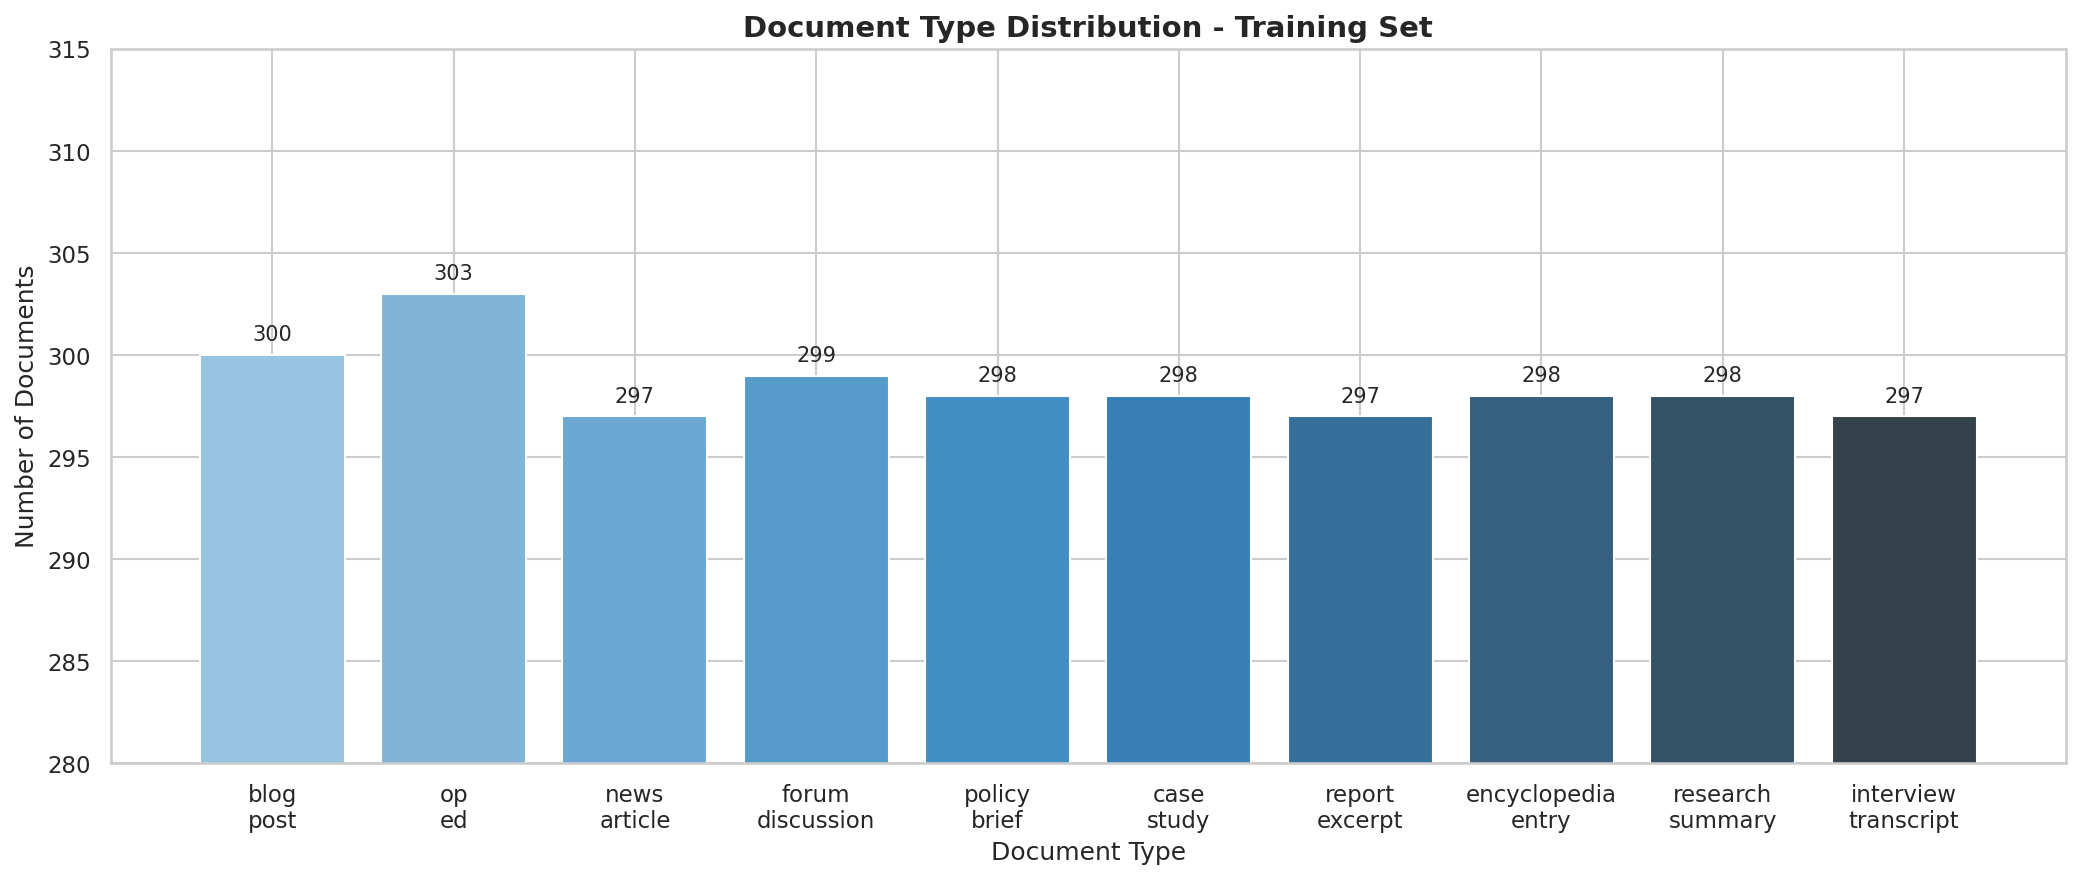

In [ ]:
doc_types = Counter([ex['document_type'] for ex in dataset['train']])
genres = [g.replace('_', '\n') for g in doc_types.keys()]
counts = list(doc_types.values())

plt.figure(figsize=(14, 6))
bars = plt.bar(genres, counts, color=sns.color_palette("Blues_d", len(genres)))
plt.title('Document Type Distribution - Training Set', fontsize=14, fontweight='bold')
plt.ylabel('Number of Documents')
plt.xlabel('Document Type')
plt.ylim(280, 315)

for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(count), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(fig_path + 'genre_distribution.png', bbox_inches='tight')
plt.show()

The Document Type Distribution - Training Set bar chart shows the frequency of different document genres within the training dataset. Each bar represents a document type (e.g., 'blog post', 'op ed', 'forum discussion'), and its height indicates the number of documents belonging to that genre. As the distribution is quite balanced across the different document types, with each genre having approximately 297 to 303 documents.

### Label Count Distribution

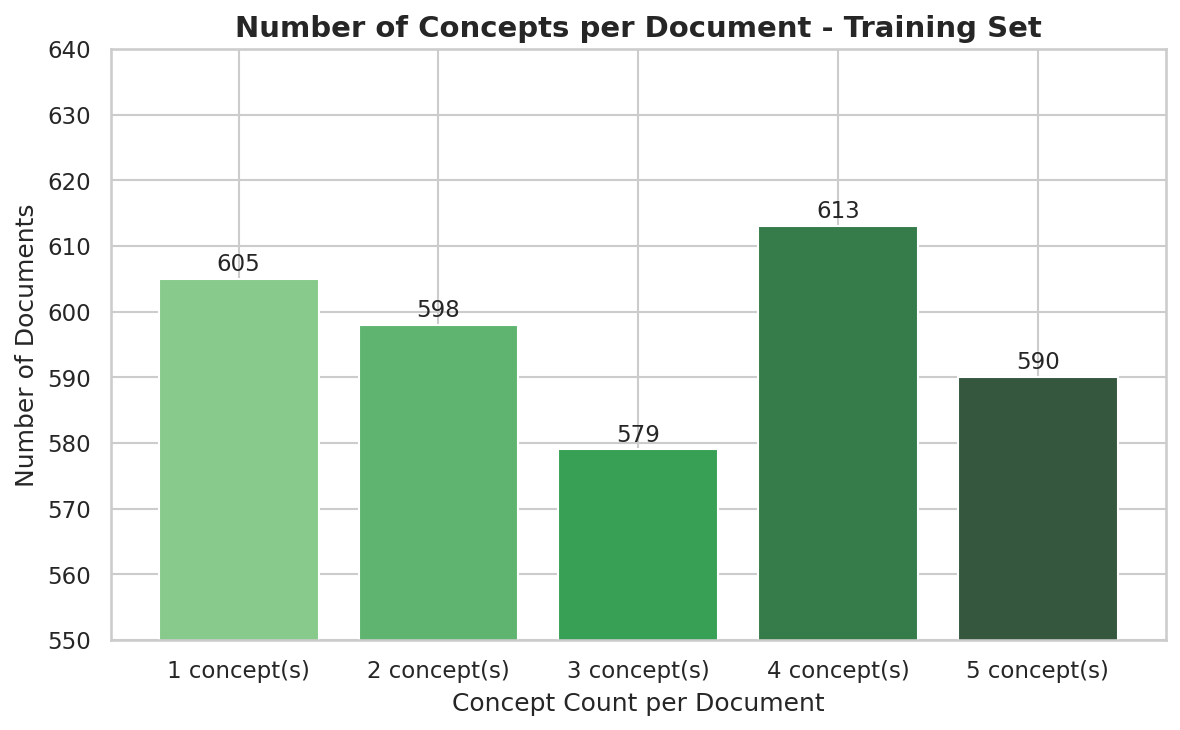

In [ ]:
label_counts = Counter([len(ex['retrieval_labels']['positive_ids'])
                        for ex in dataset['train']])

labels = [f"{k} concept(s)" for k in sorted(label_counts.keys())]
values = [label_counts[k] for k in sorted(label_counts.keys())]

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, values, color=sns.color_palette("Greens_d", len(labels)))
plt.title('Number of Concepts per Document - Training Set',
          fontsize=14, fontweight='bold')
plt.ylabel('Number of Documents')
plt.xlabel('Concept Count per Document')
plt.ylim(550, 640)

for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(val), ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig(fig_path + 'label_distribution.png', bbox_inches='tight')
plt.show()

The Number of Concepts per Document - Training Set bar chart illustrates how many concepts are associated with each document in the training set. Each bar represents a specific number of concepts (e.g., '1 concept(s)', '2 concept(s)'), and its height indicates the frequency, or number of documents, that have that many concepts. The chart shows that the distribution is relatively balanced, with each concept count from 1 to 5 appearing in approximately 579 to 613 documents.

### Passage Length Histogram

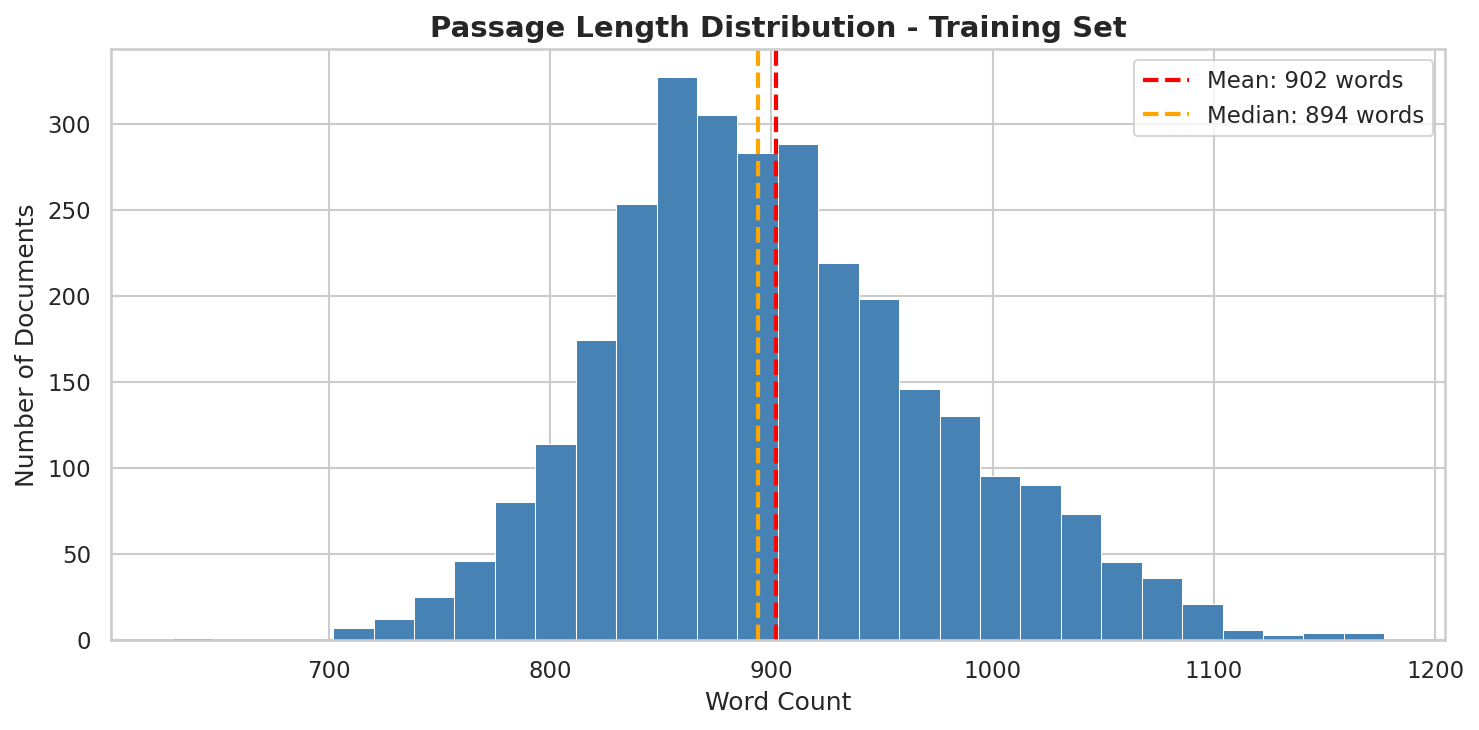

In [ ]:
lengths = [len(ex['text'].split()) for ex in dataset['train']]

plt.figure(figsize=(10, 5))
plt.hist(lengths, bins=30, color='steelblue', edgecolor='white', linewidth=0.5)
plt.axvline(np.mean(lengths), color='red', linestyle='--',
            linewidth=2, label=f'Mean: {np.mean(lengths):.0f} words')
plt.axvline(np.median(lengths), color='orange', linestyle='--',
            linewidth=2, label=f'Median: {np.median(lengths):.0f} words')

plt.title('Passage Length Distribution - Training Set',
          fontsize=14, fontweight='bold')
plt.xlabel('Word Count')
plt.ylabel('Number of Documents')
plt.legend()
plt.tight_layout()
plt.savefig(fig_path + 'passage_length_distribution.png', bbox_inches='tight')
plt.show()

The Passage Length Distribution - Training Set histogram visualizes the distribution of document lengths (in words) within the training dataset. Each bar represents a range of word counts, and its height indicates the number of documents that fall within that length range. The red dashed line shows the mean passage length, which is approximately 902 words, and the orange dashed line indicates the median passage length, around 894 words. This suggests that the document lengths are somewhat symmetrically distributed around the central values, without extreme skewness, and that most passages are relatively long.

### Definition length Histogram

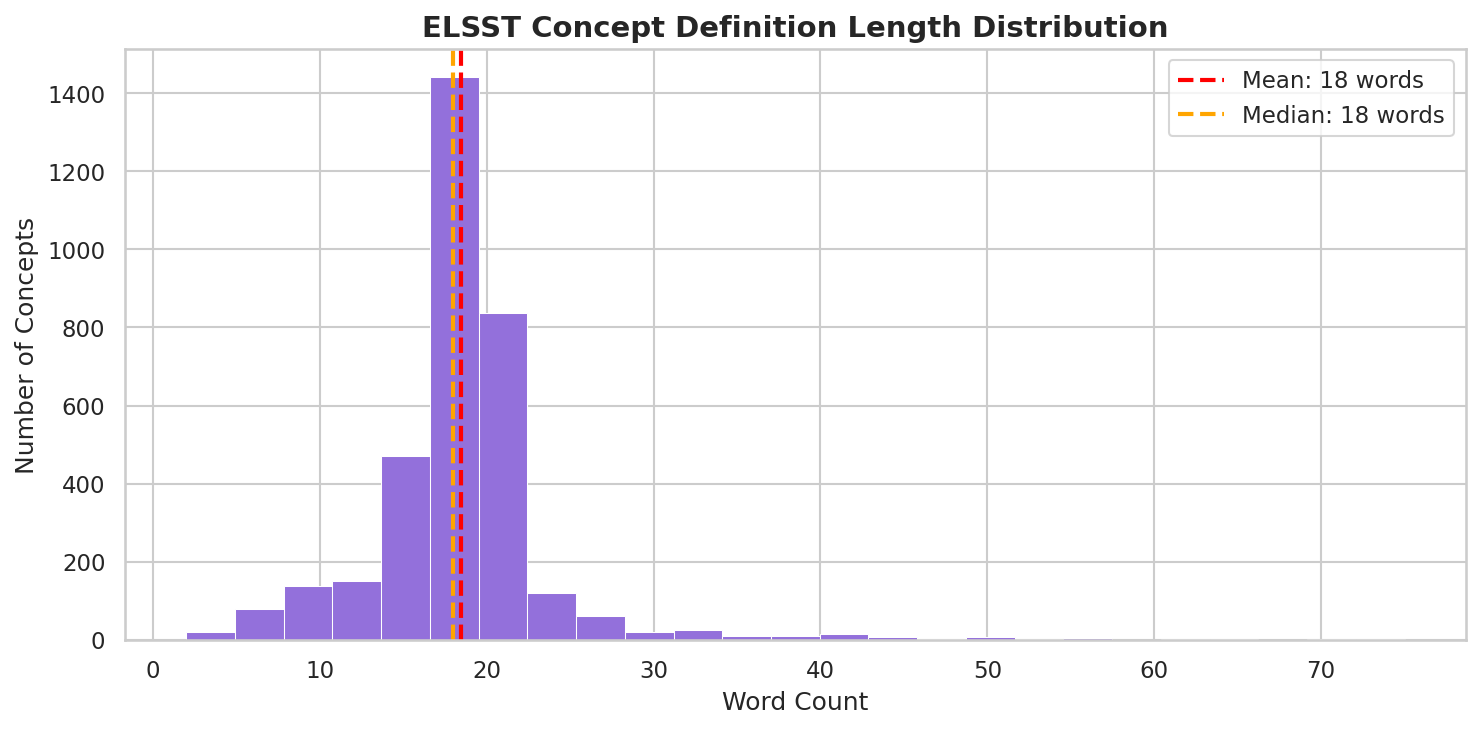

In [ ]:
def_lengths = [len(c['definition'].split()) for c in unique_concepts]

plt.figure(figsize=(10, 5))
plt.hist(def_lengths, bins=25, color='mediumpurple', edgecolor='white', linewidth=0.5)
plt.axvline(np.mean(def_lengths), color='red', linestyle='--',
            linewidth=2, label=f'Mean: {np.mean(def_lengths):.0f} words')
plt.axvline(np.median(def_lengths), color='orange', linestyle='--',
            linewidth=2, label=f'Median: {np.median(def_lengths):.0f} words')

plt.title('ELSST Concept Definition Length Distribution',
          fontsize=14, fontweight='bold')
plt.xlabel('Word Count')
plt.ylabel('Number of Concepts')
plt.legend()
plt.tight_layout()
plt.savefig(fig_path + 'definition_length_distribution.png', bbox_inches='tight')
plt.show()

The ELSST Concept Definition Length Distribution histogram illustrates the distribution of word counts for the definitions of the unique ELSST concepts. Each bar shows how many concepts have definitions within a particular word count range. The red dashed line marks the mean definition length, which is approximately 18 words, and the orange dashed line indicates the median definition length, also around 18 words. This suggests that concept definitions are generally quite concise, with most definitions falling close to this average length, and the distribution is fairly symmetrical without significant skewness. The minimum definition length is 3 words, and the maximum is 71 words, as previously shown.

### Top 20 Most Frequent Concepts

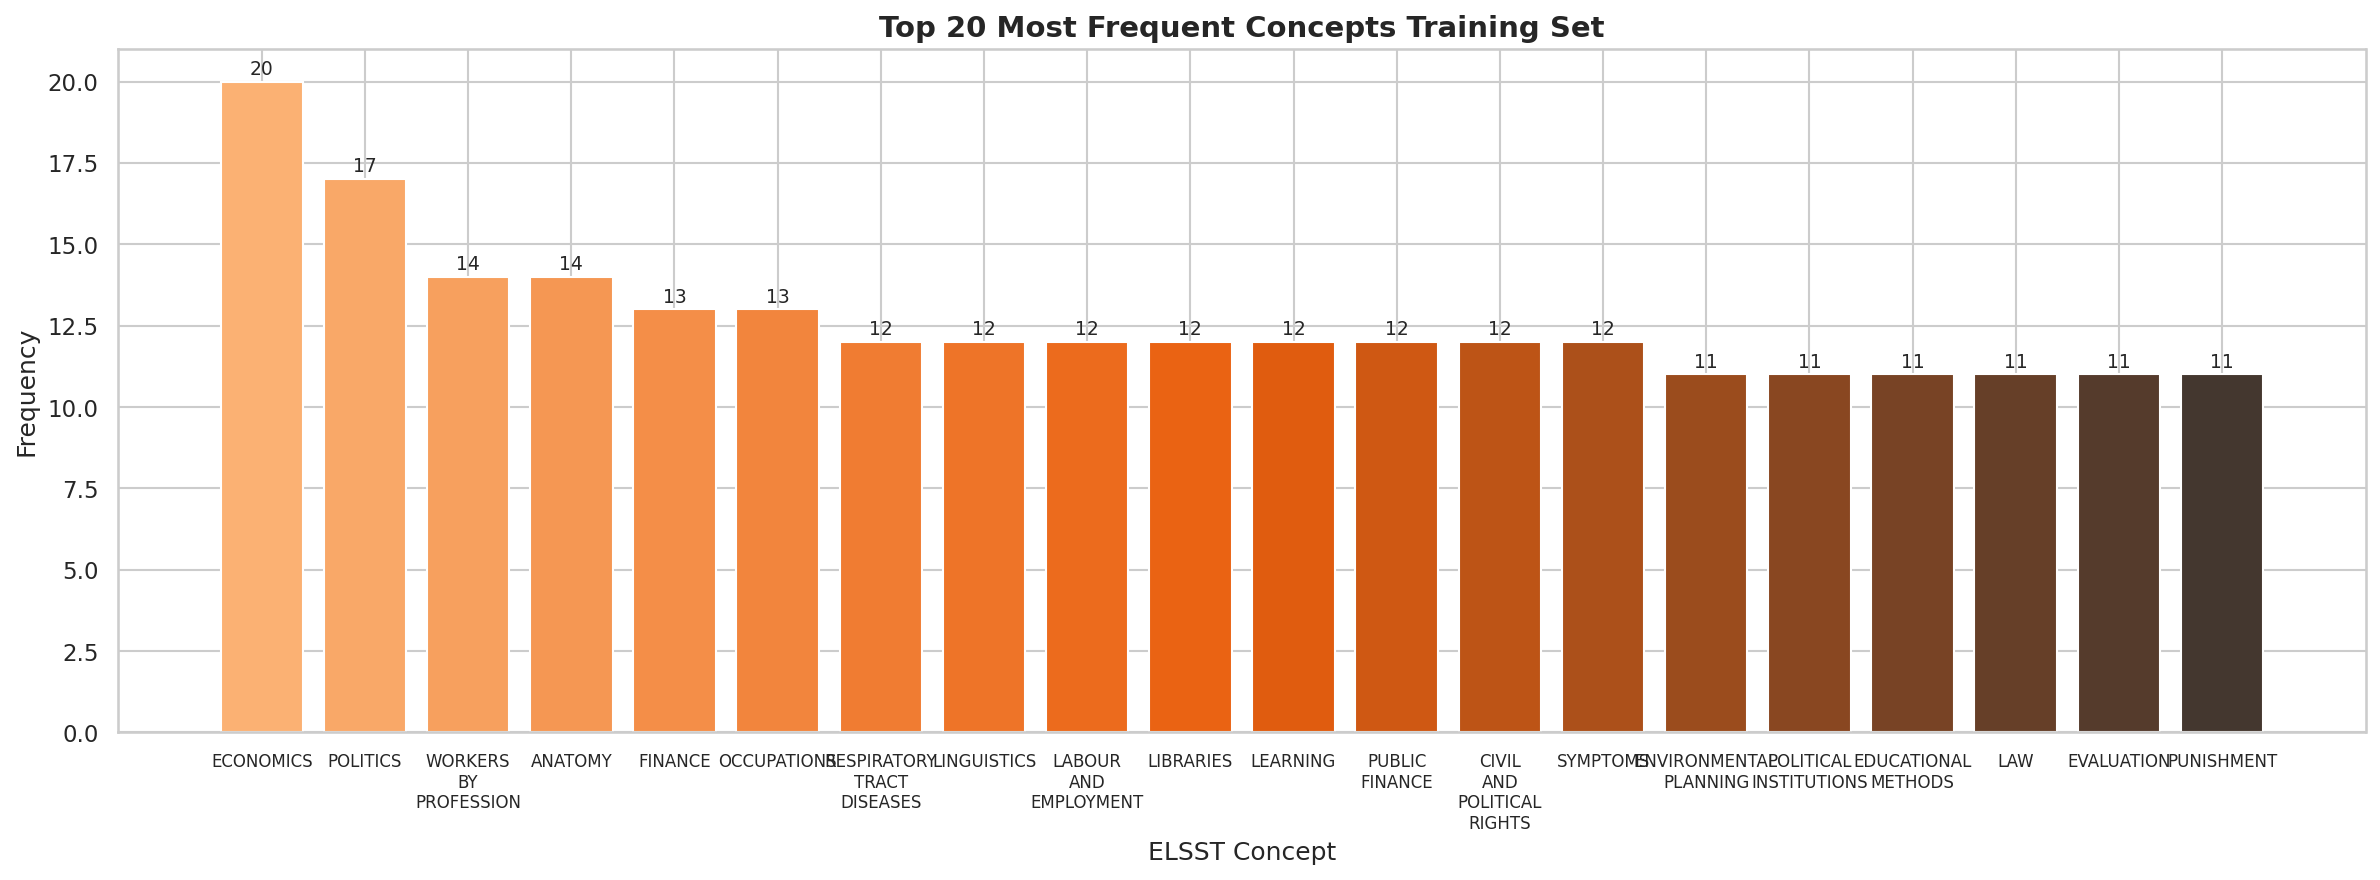

In [ ]:
all_terms = []
for ex in dataset['train']:
    for label in ex['generation_labels']:
        all_terms.append(label['term'])

term_counts = Counter(all_terms)
top_20 = term_counts.most_common(20)
terms = [t[0].replace(' ', '\n') for t in top_20]
counts = [t[1] for t in top_20]

plt.figure(figsize=(16, 6))
bars = plt.bar(terms, counts, color=sns.color_palette("Oranges_d", len(terms)))
plt.title('Top 20 Most Frequent Concepts Training Set',
          fontsize=14, fontweight='bold')
plt.ylabel('Frequency')
plt.xlabel('ELSST Concept')
plt.xticks(fontsize=8)

for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             str(count), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(fig_path + 'top20_concepts.png', bbox_inches='tight')
plt.show()

The Top 20 Most Frequent Concepts Training Set bar chart displays the 20 most commonly occurring ELSST concepts across all documents in the training set. Each bar represents a concept, and its height shows how many times that concept appears. As seen from the results, concepts like 'ECONOMICS' (20 occurrences), 'POLITICS' (17 occurrences), 'WORKERS BY PROFESSION' and 'ANATOMY' (both with 14 occurrences) are among the most frequent. This indicates the primary domains and topics covered within the training data, with a clear focus on social sciences, economics, and some specific scientific areas.

### Concept Frequency Distribution (Long Tail)

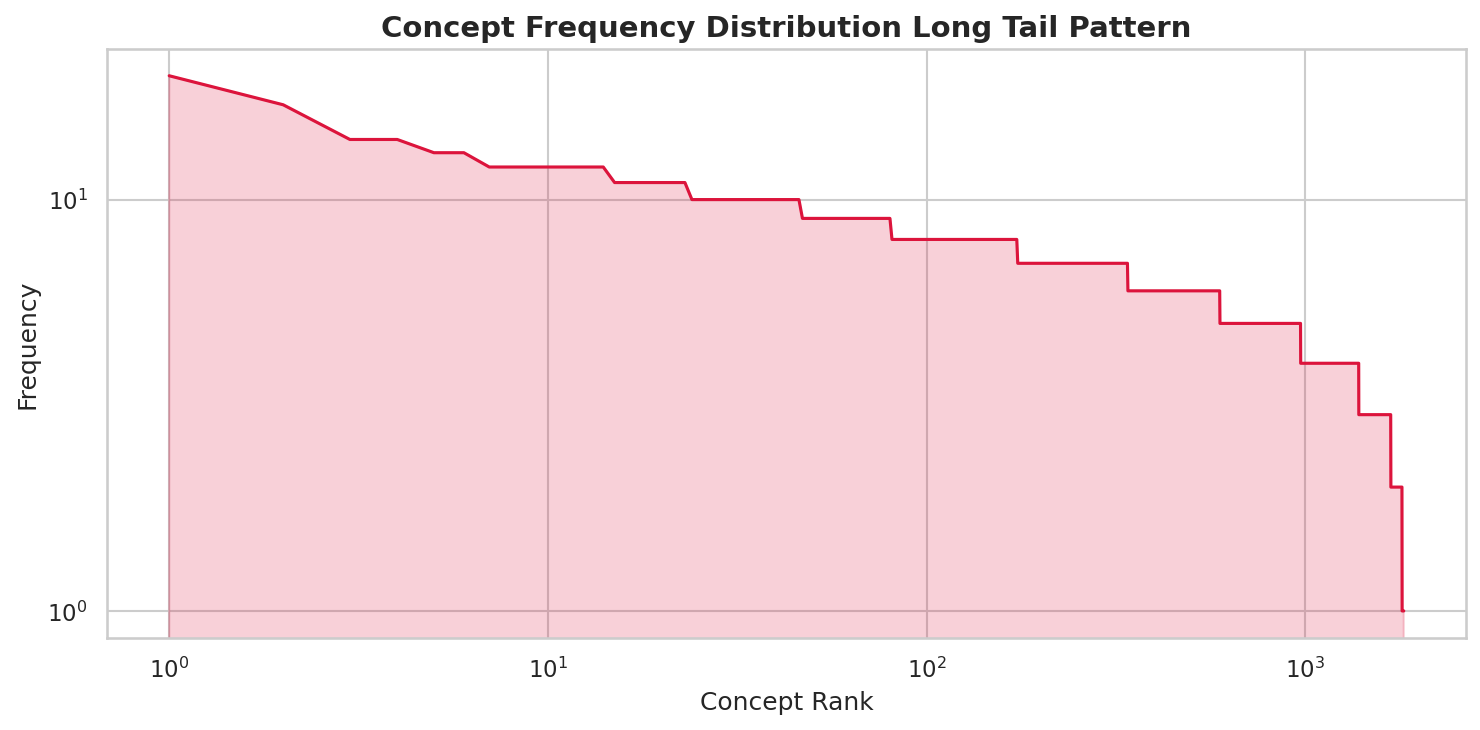

In [ ]:
all_freq = sorted(term_counts.values(), reverse=True)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(all_freq)+1), all_freq, color='crimson', linewidth=1.5)
plt.fill_between(range(1, len(all_freq)+1), all_freq, alpha=0.2, color='crimson')
plt.title('Concept Frequency Distribution Long Tail Pattern',
          fontsize=14, fontweight='bold')
plt.xlabel('Concept Rank')
plt.ylabel('Frequency')
plt.yscale('log')
plt.xscale('log')
plt.tight_layout()
plt.savefig(fig_path + 'concept_frequency_longtail.png', bbox_inches='tight')
plt.show()

The Concept Frequency Distribution Long Tail Pattern graph visualizes the frequency of ELSST concepts when ranked from most to least frequent, with both axes on a logarithmic scale. The x-axis represents the rank of the concept (from 1st most frequent to the least frequent), and the y-axis shows its corresponding frequency (how many documents it appears in). The distinct 'long tail' pattern shows that a small number of concepts appear very frequently, while a large number of concepts appear only a few times. This is a common distribution in many real-world datasets, indicating that only a few topics are highly dominant, while many others are niche or appear rarely.

### Cross-Split Comparison (Train vs Val)

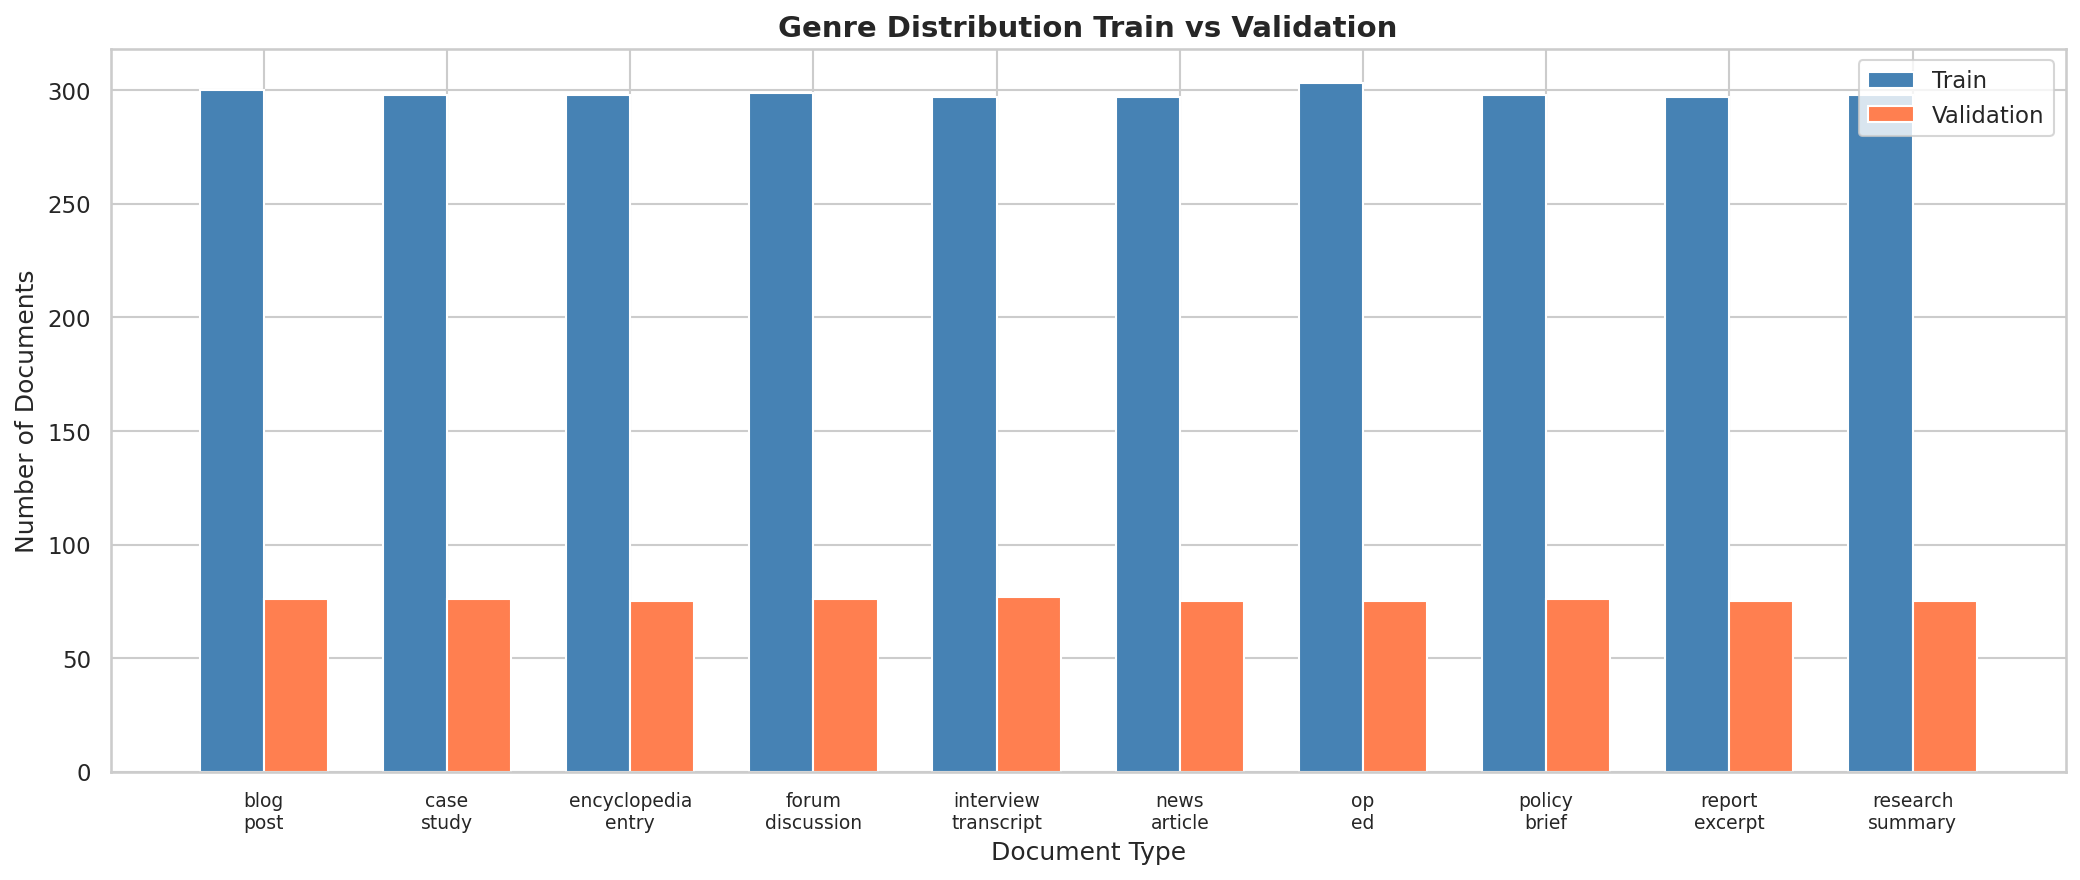

In [ ]:
train_genres = Counter([ex['document_type'] for ex in dataset['train']])
val_genres = Counter([ex['document_type'] for ex in dataset['validation']])

genres = sorted(train_genres.keys())
train_vals = [train_genres[g] for g in genres]
val_vals = [val_genres[g] for g in genres]

x = np.arange(len(genres))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2, train_vals, width, label='Train', color='steelblue')
bars2 = ax.bar(x + width/2, val_vals, width, label='Validation', color='coral')

ax.set_title('Genre Distribution Train vs Validation',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Documents')
ax.set_xlabel('Document Type')
ax.set_xticks(x)
ax.set_xticklabels([g.replace('_', '\n') for g in genres], fontsize=9)
ax.legend()

plt.tight_layout()
plt.savefig(fig_path + 'cross_split_genre.png', bbox_inches='tight')
plt.show()

The Genre Distribution Train vs Validation bar chart visually compares the distribution of document types (genres) between the training and validation datasets. For each genre, there are two adjacent bars: one representing the count of documents in the training set (blue) and the other for the validation set (coral). This visualization clearly shows that the genre distribution is consistent across both splits, meaning each document type is represented proportionally in both the training and validation sets. This is important for ensuring that models trained on this data will be exposed to a similar variety of document types during validation, providing a more reliable evaluation of their performance.

### Concept Overlap Pie Chart

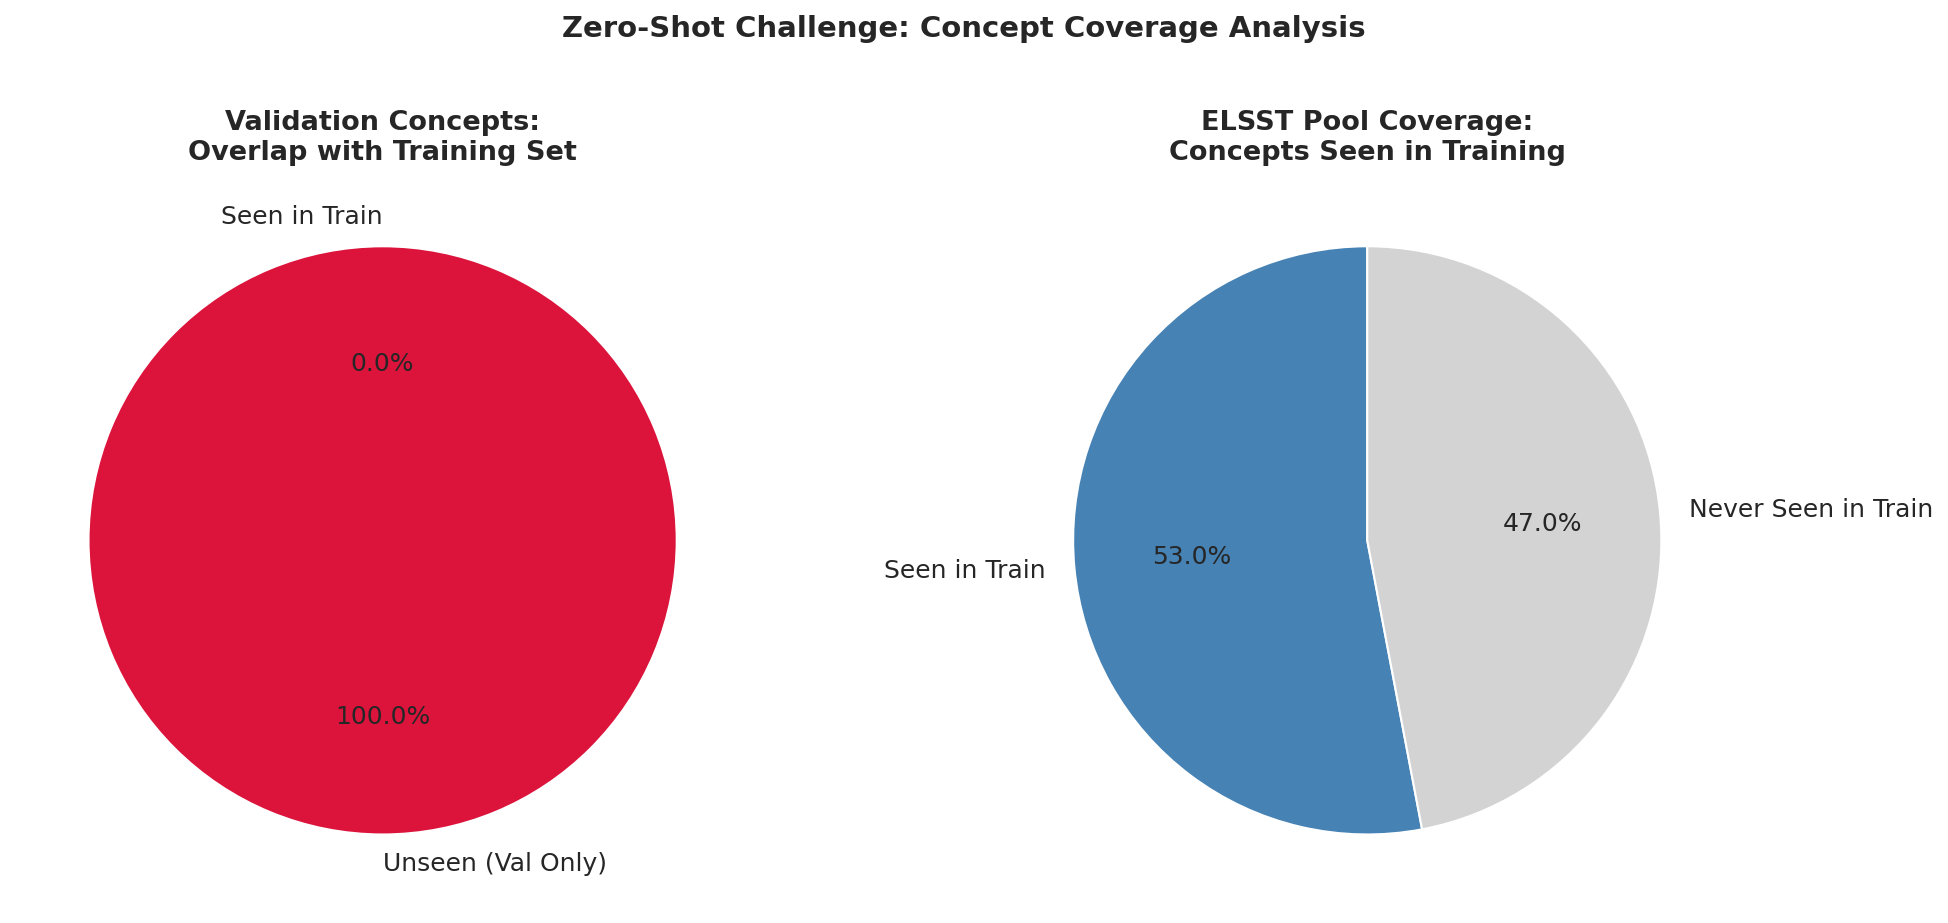

In [ ]:
train_ids = set()
for ex in dataset['train']:
    for label in ex['generation_labels']:
        train_ids.add(label['concept_id'])

val_ids = set()
for ex in dataset['validation']:
    for label in ex['generation_labels']:
        val_ids.add(label['concept_id'])

overlap = len(train_ids.intersection(val_ids))
val_only = len(val_ids - train_ids)
unseen_in_pool = 3433 - len(train_ids)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left — Validation concept overlap
axes[0].pie([overlap, val_only],
            labels=['Seen in Train', 'Unseen (Val Only)'],
            colors=['steelblue', 'crimson'],
            autopct='%1.1f%%',
            startangle=90,
            textprops={'fontsize': 12})
axes[0].set_title('Validation Concepts:\nOverlap with Training Set',
                  fontsize=13, fontweight='bold')

# Right — Full concept pool coverage
seen = len(train_ids)
unseen = 3433 - seen
axes[1].pie([seen, unseen],
            labels=['Seen in Train', 'Never Seen in Train'],
            colors=['steelblue', 'lightgrey'],
            autopct='%1.1f%%',
            startangle=90,
            textprops={'fontsize': 12})
axes[1].set_title('ELSST Pool Coverage:\nConcepts Seen in Training',
                  fontsize=13, fontweight='bold')

plt.suptitle('Zero-Shot Challenge: Concept Coverage Analysis',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(fig_path + 'concept_overlap.png', bbox_inches='tight')
plt.show()

The Zero-Shot Challenge: Concept Coverage Analysis figure displays two pie charts to illustrate concept overlap and coverage. The chart on the left, 'Validation Concepts: Overlap with Training Set,' shows that 0.0% of the concepts found in the validation set are also present in the training set. This means 100% of the validation concepts (454 out of 454) are entirely unseen in the training data, which poses a significant 'zero-shot' challenge. The chart on the right, 'ELSST Pool Coverage: Concepts Seen in Training,' indicates that out of the total ELSST concept pool of 3433 concepts, 53.0% (1819 concepts) are seen in the training set, while 47.0% (1614 concepts) are never encountered during training. These findings highlight the difficulty of the task, as a model will need to generalize to entirely new concepts during evaluation.

## 4. Cross-Split Comparison (All Splits)

### Genre Distribution All Split

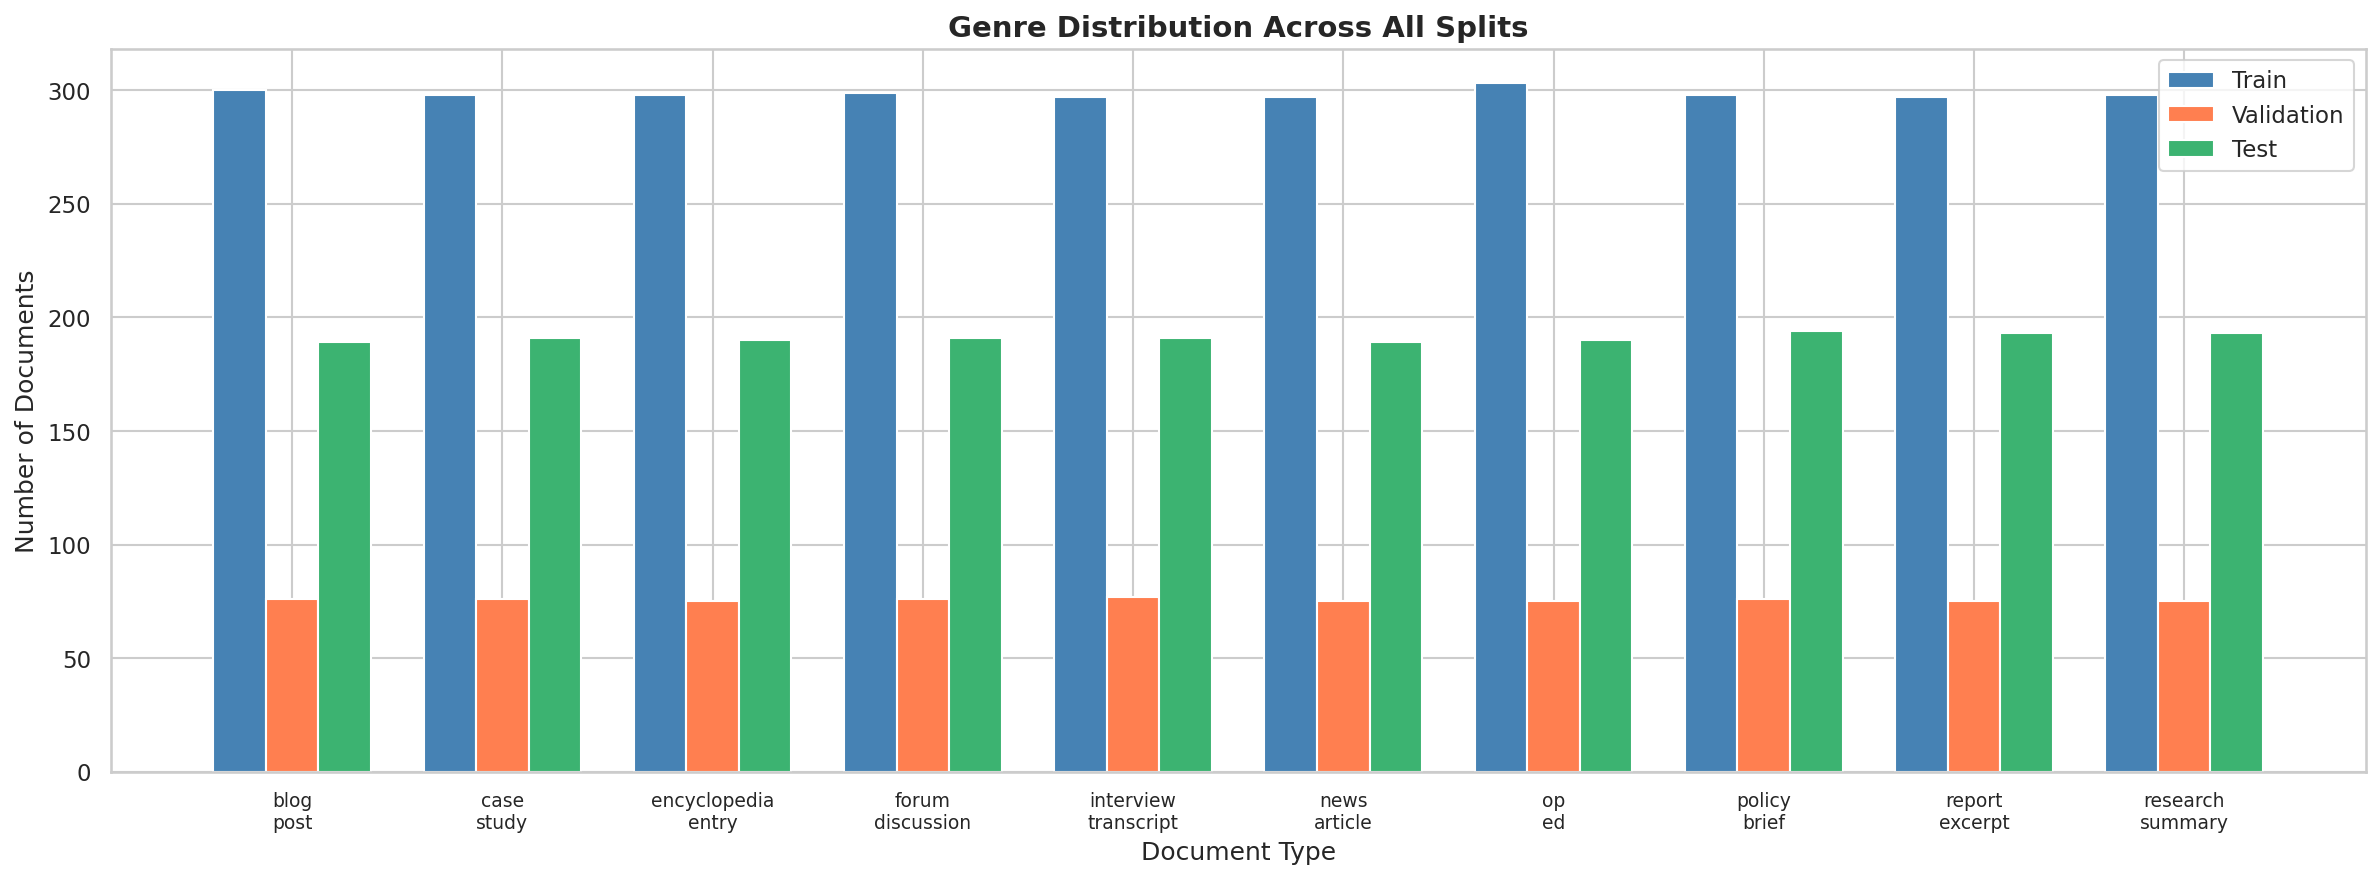

Saved!


In [ ]:
train_genres = Counter([ex['document_type'] for ex in dataset['train']])
val_genres = Counter([ex['document_type'] for ex in dataset['validation']])
test_genres = Counter([ex['document_type'] for ex in dataset['test']])

genres = sorted(train_genres.keys())
x = np.arange(len(genres))
width = 0.25

fig, ax = plt.subplots(figsize=(16, 6))
bars1 = ax.bar(x - width, [train_genres[g] for g in genres],
               width, label='Train', color='steelblue')
bars2 = ax.bar(x, [val_genres[g] for g in genres],
               width, label='Validation', color='coral')
bars3 = ax.bar(x + width, [test_genres[g] for g in genres],
               width, label='Test', color='mediumseagreen')

ax.set_title('Genre Distribution Across All Splits',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Documents')
ax.set_xlabel('Document Type')
ax.set_xticks(x)
ax.set_xticklabels([g.replace('_', '\n') for g in genres], fontsize=9)
ax.legend()

plt.tight_layout()
plt.savefig(fig_path + 'genre_distribution_all_splits.png', bbox_inches='tight')
plt.show()
print("Saved!")

### Label Count All Split

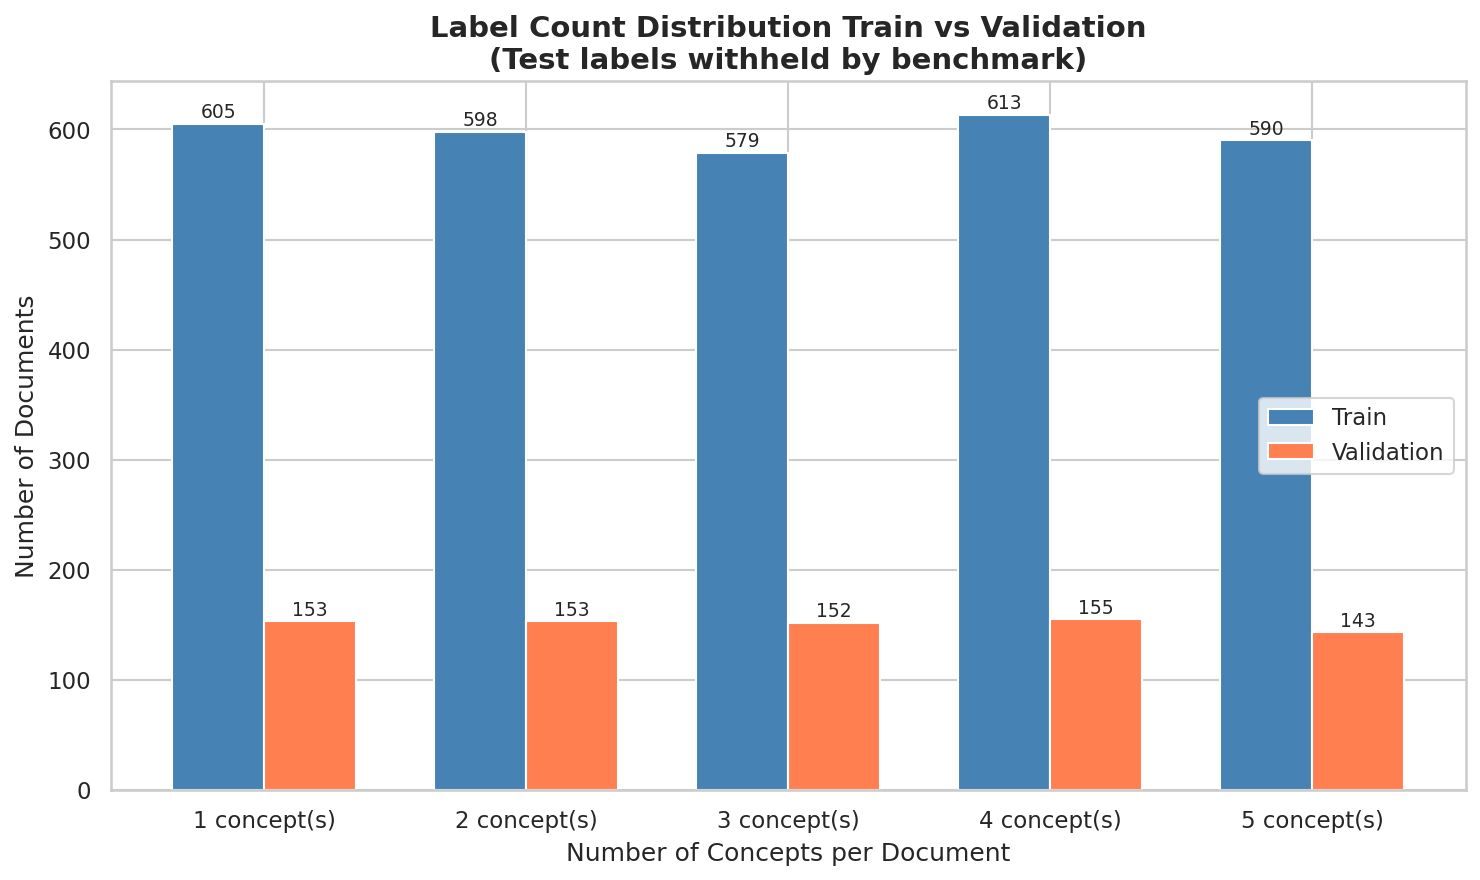

Saved!


In [ ]:
train_labels = Counter([len(ex['retrieval_labels']['positive_ids'])
                        for ex in dataset['train']])
val_labels = Counter([len(ex['retrieval_labels']['positive_ids'])
                      for ex in dataset['validation']])

x = np.arange(5)
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, [train_labels[i+1] for i in range(5)],
               width, label='Train', color='steelblue')
bars2 = ax.bar(x + width/2, [val_labels[i+1] for i in range(5)],
               width, label='Validation', color='coral')

ax.set_title('Label Count Distribution Train vs Validation\n'
             '(Test labels withheld by benchmark)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Documents')
ax.set_xlabel('Number of Concepts per Document')
ax.set_xticks(x)
ax.set_xticklabels([f'{i+1} concept(s)' for i in range(5)])
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(fig_path + 'label_distribution_all_splits.png', bbox_inches='tight')
plt.show()
print("Saved!")

### Passage Length All Splits

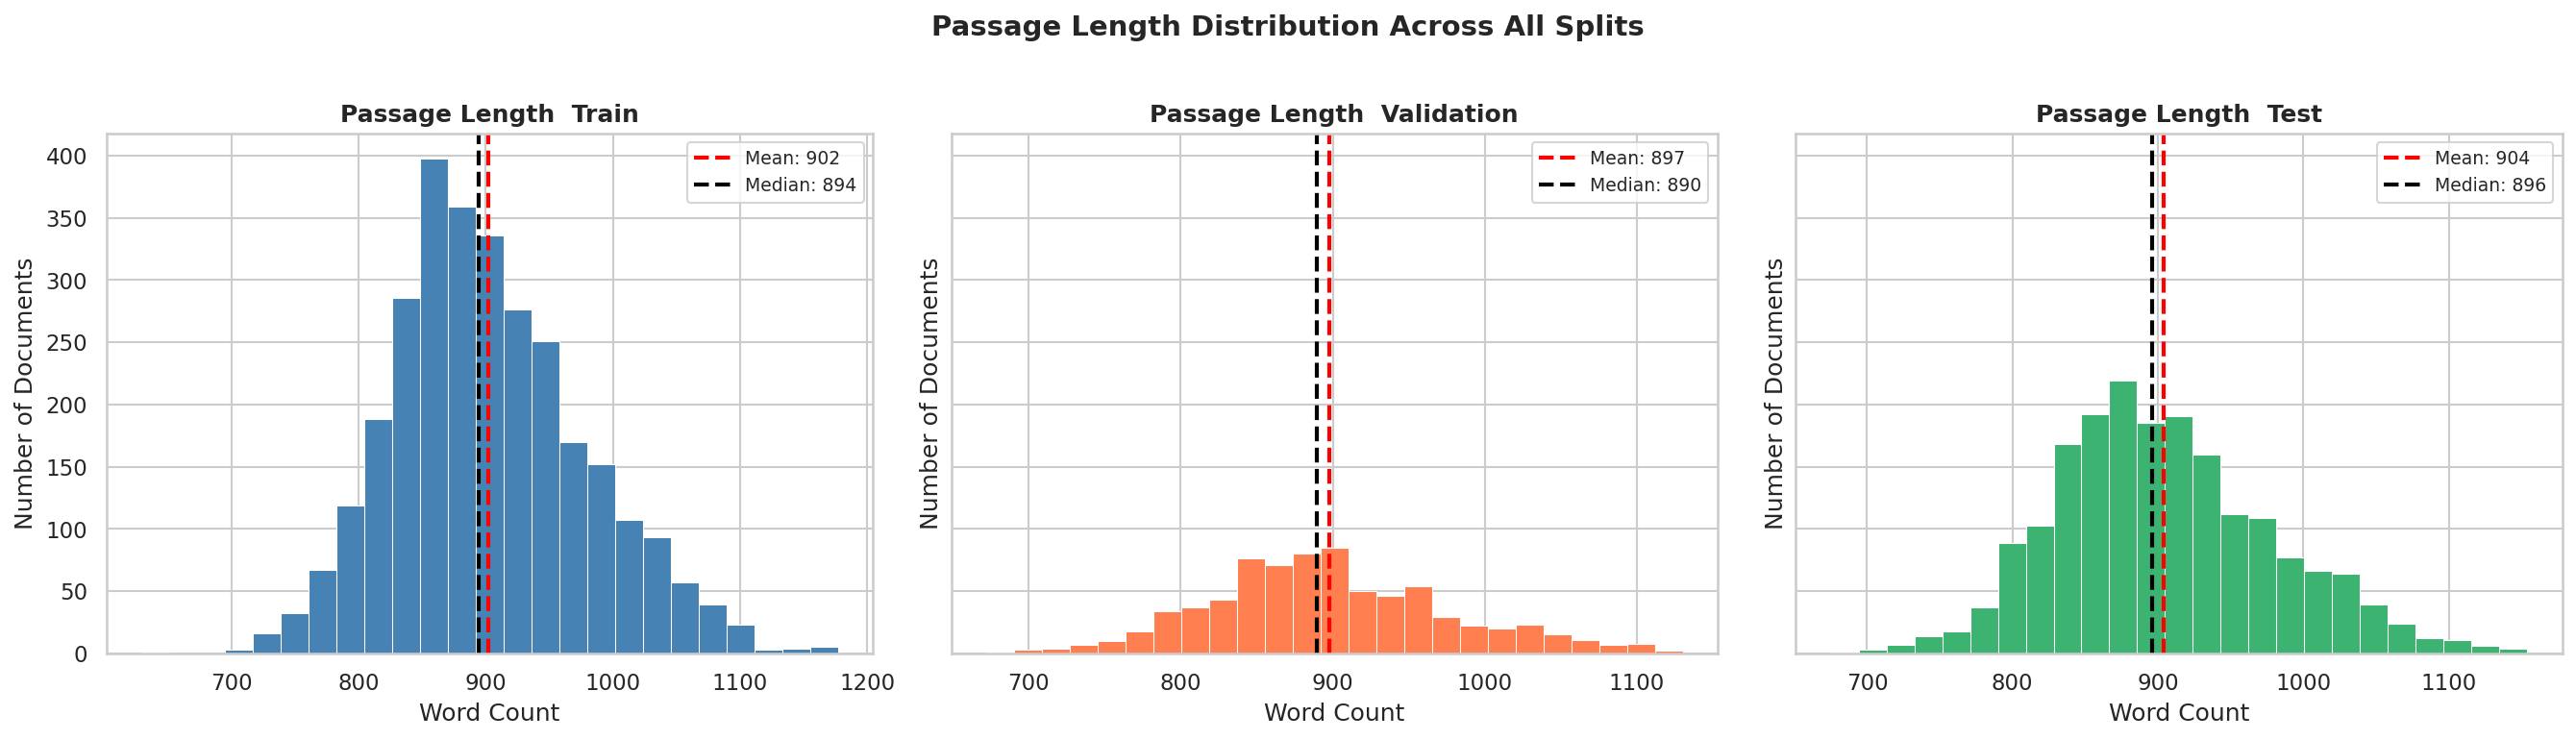

Saved!


In [ ]:
train_lengths = [len(ex['text'].split()) for ex in dataset['train']]
val_lengths = [len(ex['text'].split()) for ex in dataset['validation']]
test_lengths = [len(ex['text'].split()) for ex in dataset['test']]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

splits = [
    (train_lengths, 'Train', 'steelblue'),
    (val_lengths, 'Validation', 'coral'),
    (test_lengths, 'Test', 'mediumseagreen')
]

for ax, (lengths, split_name, color) in zip(axes, splits):
    ax.hist(lengths, bins=25, color=color, edgecolor='white', linewidth=0.5)
    ax.axvline(np.mean(lengths), color='red', linestyle='--',
               linewidth=2, label=f'Mean: {np.mean(lengths):.0f}')
    ax.axvline(np.median(lengths), color='black', linestyle='--',
               linewidth=2, label=f'Median: {np.median(lengths):.0f}')
    ax.set_title(f'Passage Length  {split_name}', fontweight='bold')
    ax.set_xlabel('Word Count')
    ax.set_ylabel('Number of Documents')
    ax.legend(fontsize=9)

plt.suptitle('Passage Length Distribution Across All Splits',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(fig_path + 'passage_length_all_splits.png', bbox_inches='tight')
plt.show()
print("Saved!")

### Top 20 Concepts Train vs Val (all side by side)

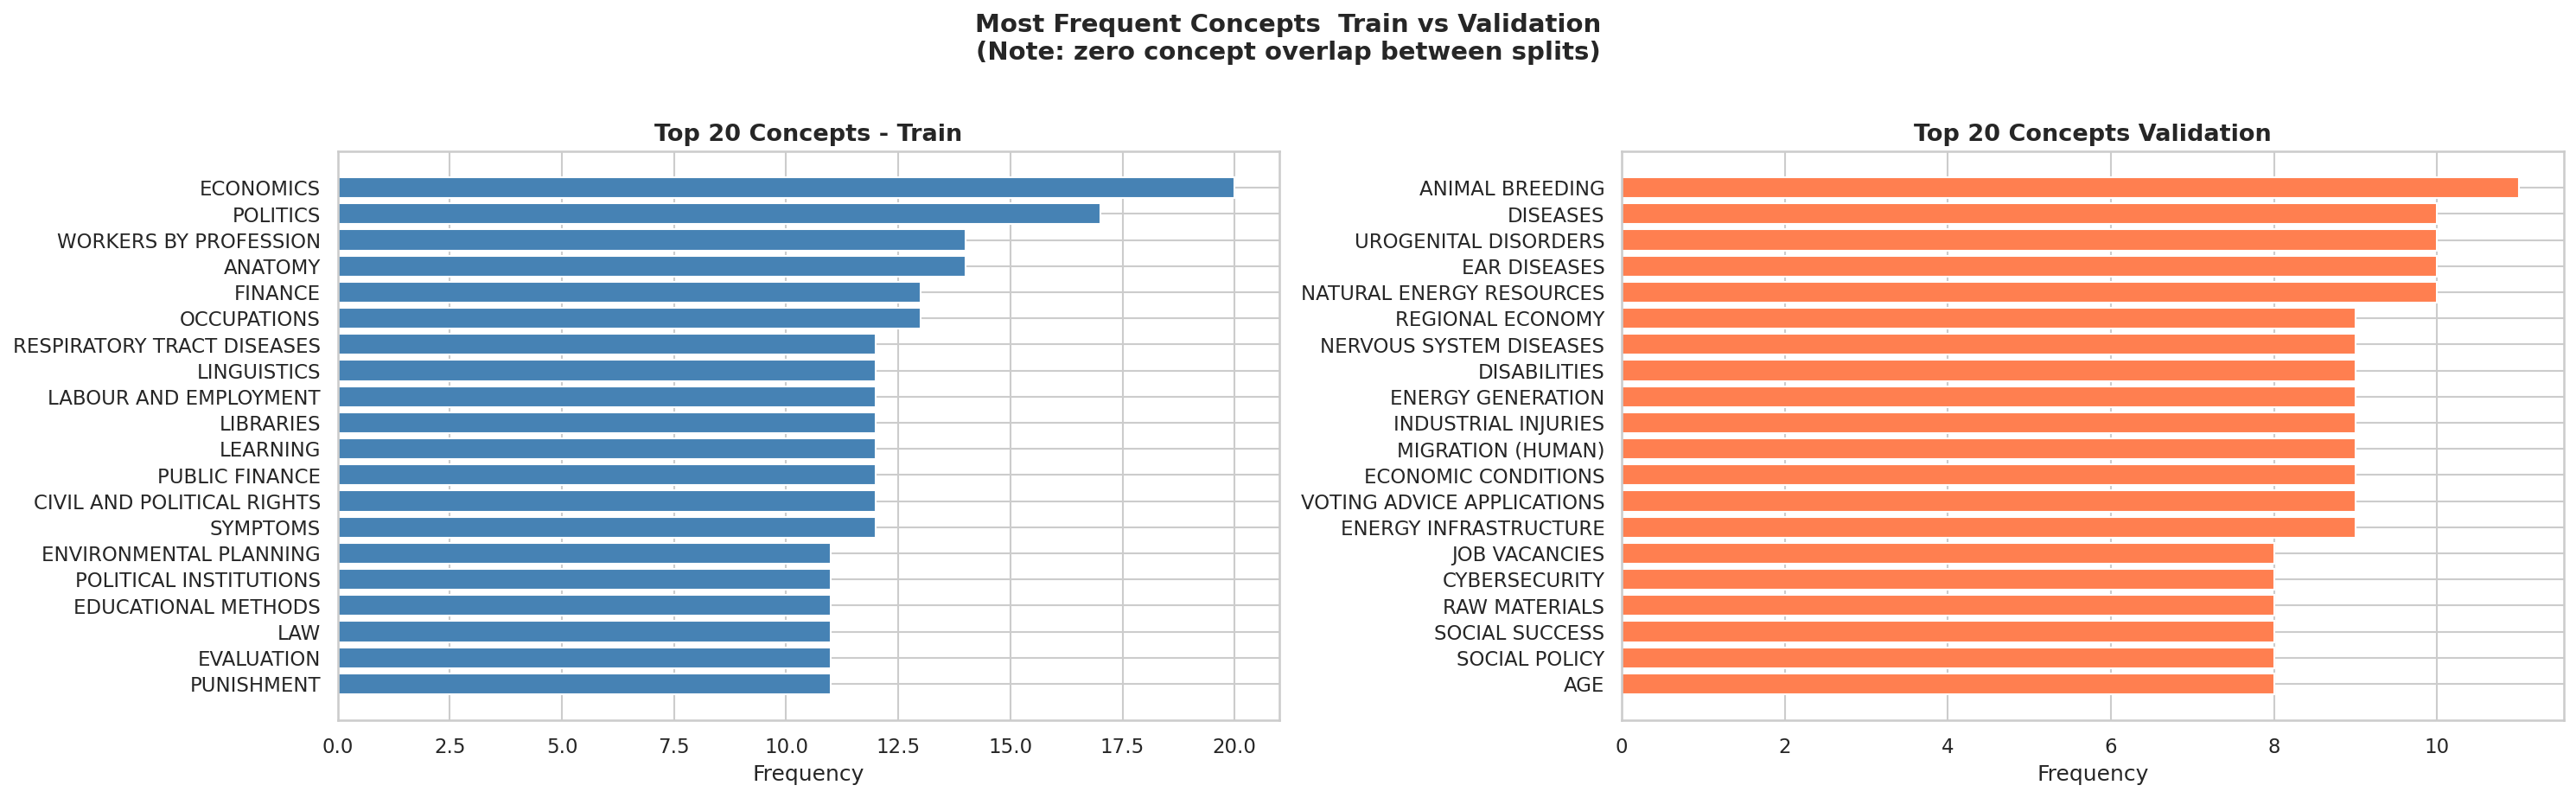

Saved!


In [ ]:
train_terms = Counter()
for ex in dataset['train']:
    for label in ex['generation_labels']:
        train_terms[label['term']] += 1

val_terms = Counter()
for ex in dataset['validation']:
    for label in ex['generation_labels']:
        val_terms[label['term']] += 1

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

top_train = train_terms.most_common(20)
axes[0].barh([t[0] for t in reversed(top_train)],
             [t[1] for t in reversed(top_train)],
             color='steelblue')
axes[0].set_title('Top 20 Concepts - Train', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Frequency')

top_val = val_terms.most_common(20)
axes[1].barh([t[0] for t in reversed(top_val)],
             [t[1] for t in reversed(top_val)],
             color='coral')
axes[1].set_title('Top 20 Concepts Validation', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Frequency')

plt.suptitle('Most Frequent Concepts  Train vs Validation\n'
             '(Note: zero concept overlap between splits)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(fig_path + 'top20_concepts_all_splits.png', bbox_inches='tight')
plt.show()
print("Saved!")

### Long Tail All Splits

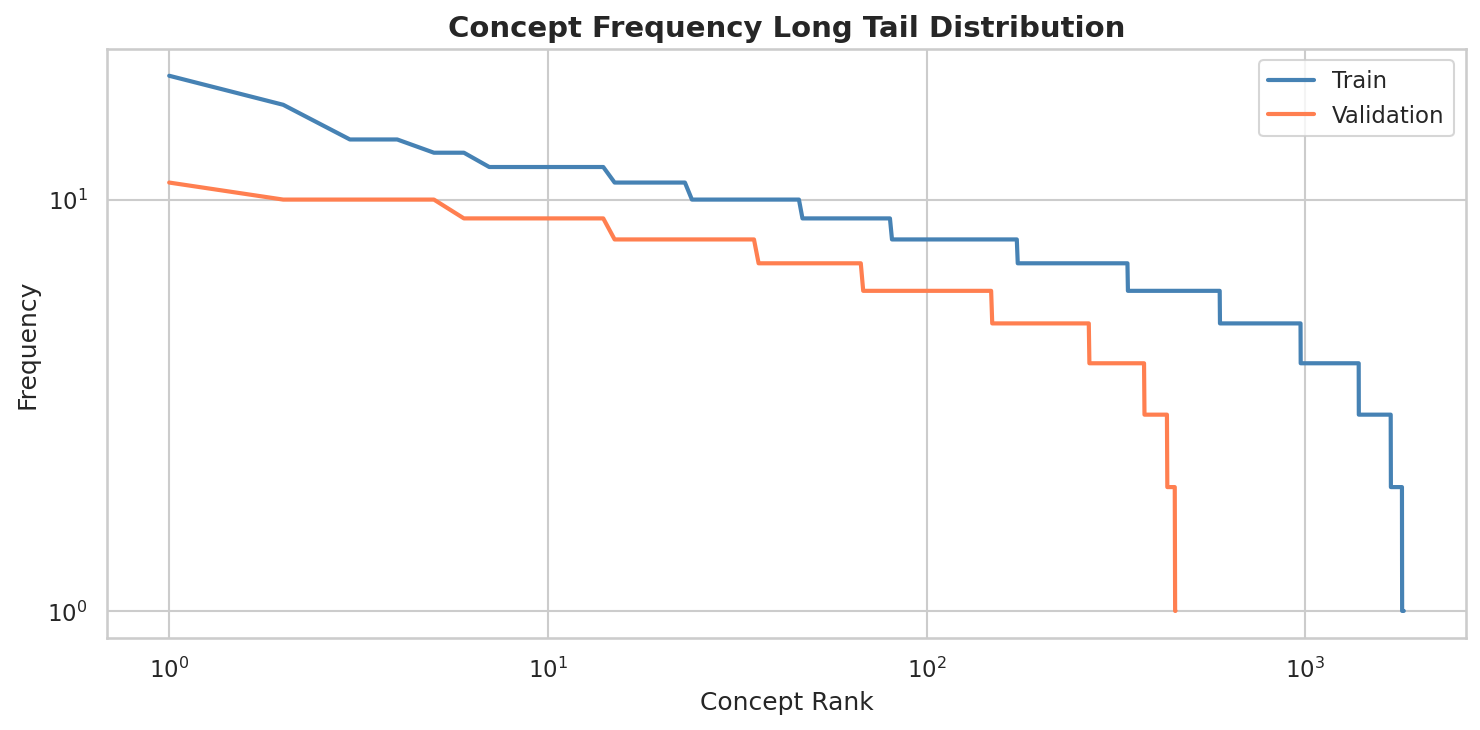

Saved!


In [ ]:
train_freq = sorted(train_terms.values(), reverse=True)
val_freq = sorted(val_terms.values(), reverse=True)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(train_freq)+1), train_freq,
         color='steelblue', linewidth=2, label='Train')
plt.plot(range(1, len(val_freq)+1), val_freq,
         color='coral', linewidth=2, label='Validation')

plt.title('Concept Frequency Long Tail Distribution',
          fontsize=14, fontweight='bold')
plt.xlabel('Concept Rank')
plt.ylabel('Frequency')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.tight_layout()
plt.savefig(fig_path + 'longtail_all_splits.png', bbox_inches='tight')
plt.show()
print("Saved!")